In [1]:
# --------------------------------
# Imports & Path Setup
# --------------------------------

%reload_ext autoreload
%autoreload 2

import os
print(os.getcwd())

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

import numpy as np
import matplotlib.pyplot as plt
import torch
from skimage.metrics import peak_signal_noise_ratio as calc_psnr
from skimage.metrics import structural_similarity as calc_ssim

from src.models.restormer import RestormerModel

from src.utils.trainer import Trainer
from src.utils.logger import Logger

/hpc/home/efavale/deep-image-restoration


In [6]:
# --------------------------------
# Trainer Setup
# --------------------------------

LOG_DIR = Path("logs")

RESIZED_DIR = Path("data/resized")
COMPRESSED_DIR = Path("data/compressed")
CHECKPOINTS_DIR = Path("checkpoints")

logger = Logger(
    dir=LOG_DIR,
    description="RestormerModel-Fourier"
)

model = RestormerModel(logger=logger)

# RestormerModel
trainer = Trainer(
    input_dir=RESIZED_DIR,
    compressed_dir=COMPRESSED_DIR,
    checkpoints_dir=CHECKPOINTS_DIR,
    checkpoint_name="best_model_restormer_fourier",
    model=model,
    batch_size=4,
    learning_rate=1e-3,
    weight_decay=1e-4,
    num_workers=0,
    train_restriction="fourier_only"
)

trainer.load_dataset()

Device : cuda
Parameters : 26,126,644
Train	| Val	| Test : 
350	| 75	| 75


In [3]:
# --------------------------------
# Training
# --------------------------------

history = trainer.train(num_epochs=50)

Epoch   1/50  |  Train Loss: 0.686573  |  Val Loss:   0.383042
Epoch  10/50  |  Train Loss: 0.145008  |  Val Loss:   0.156541
Epoch  20/50  |  Train Loss: 0.135405  |  Val Loss:   0.149683
Epoch  30/50  |  Train Loss: 0.128922  |  Val Loss:   0.146987
Epoch  40/50  |  Train Loss: 0.126261  |  Val Loss:   0.141296
Epoch  50/50  |  Train Loss: 0.123184  |  Val Loss:   0.142212

Training complete — Best val loss: 0.141141 (epoch 47)
Checkpoint saved: checkpoints/best_model_restormer_fourier_20260330_162035.pth
[Logger] Log saved to: logs/20260330_162035_RestormerModel-Fourier.log


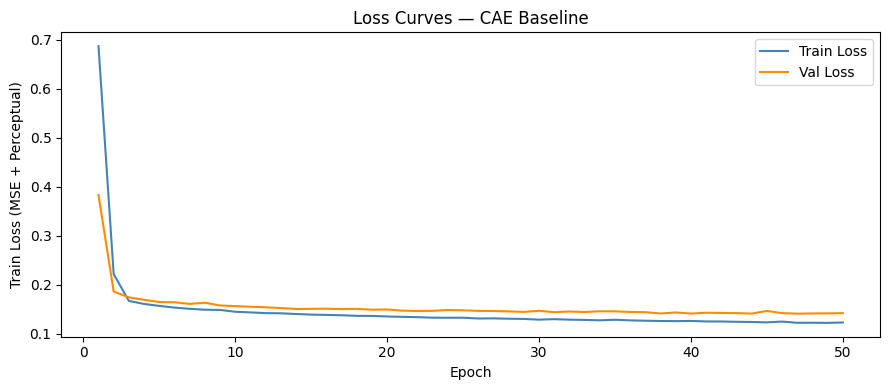

In [4]:
# --------------------------------
# Loss Curves
# --------------------------------

epochs = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(9, 4))
plt.plot(epochs, history["train_loss"], label="Train Loss", color="steelblue")
plt.plot(epochs, history["val_loss"], label="Val Loss", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("Train Loss (MSE + Perceptual)")
plt.title("Loss Curves — CAE Baseline")
plt.legend()
plt.tight_layout()
plt.show()

In [3]:
# --------------------------------
# Load Best Checkpoint
# --------------------------------

trainer.model.load_state_dict(
    torch.load(
        Path("checkpoints/best_model_restormer_fourier_20260330_162035.pth"), map_location=trainer.device
    )
)
trainer.model.eval()
print(" Best model loaded")

 Best model loaded


In [4]:
# --------------------------------
# Baseline PSNR — Compressed vs Original
# --------------------------------

psnr_baseline, ssim_baseline = [], []

for compressed, original in trainer.test_loader:
    for comp_t, orig_t in zip(compressed.numpy(), original.numpy()):
        comp_np = np.transpose(comp_t, (1, 2, 0))
        orig_np = np.transpose(orig_t, (1, 2, 0))
        psnr_baseline.append(calc_psnr(orig_np, comp_np, data_range=1.0))
        ssim_baseline.append(
            calc_ssim(orig_np, comp_np, data_range=1.0, channel_axis=2)
        )

psnr_base = np.mean(psnr_baseline)
ssim_base = np.mean(ssim_baseline)
print(f"Baseline  —  PSNR: {psnr_base:.2f} dB  |  SSIM: {ssim_base:.4f}")

Baseline  —  PSNR: 26.21 dB  |  SSIM: 0.7464


In [7]:
# --------------------------------
# PSNR / SSIM — Restored vs Original
# --------------------------------

psnr_list, ssim_list = [], []

with torch.no_grad():
    for compressed, original in trainer.test_loader:
        compressed = compressed.to(trainer.device)
        original = original.to(trainer.device)
        recon, _ = trainer.model(compressed)

        for out_t, orig_t in zip(recon.cpu().numpy(), original.cpu().numpy()):
            out_np = np.transpose(out_t, (1, 2, 0))
            orig_np = np.transpose(orig_t, (1, 2, 0))
            psnr_list.append(calc_psnr(orig_np, out_np, data_range=1.0))
            ssim_list.append(calc_ssim(orig_np, out_np, data_range=1.0, channel_axis=2))

psnr_mean = np.mean(psnr_list)
ssim_mean = np.mean(ssim_list)

print(f"{'─' * 50}")
print(f"  PSNR baseline (compressed) : {psnr_base:.2f} dB")
print(
    f"  PSNR restored              : {psnr_mean:.2f} dB  ({psnr_mean - psnr_base:+.2f})"
)
print(f"  SSIM baseline (compressed) : {ssim_base:.4f}")
print(f"  SSIM restored              : {ssim_mean:.4f}  ({ssim_mean - ssim_base:+.4f})")
print(f"{'─' * 50}")

──────────────────────────────────────────────────
  PSNR baseline (compressed) : 26.21 dB
  PSNR restored              : 19.07 dB  (-7.14)
  SSIM baseline (compressed) : 0.7464
  SSIM restored              : 0.4805  (-0.2659)
──────────────────────────────────────────────────
